In [112]:
import re
import time
from collections import Counter, OrderedDict
from string import punctuation
from typing import List

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
from typing import Dict
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

nltk.download("stopwords")
sns.set(style="whitegrid", palette="Set2")

device = (
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nataly\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---

В этой задаче вам предлагается решить задачу регрессии — по текстовому описанию вакансии определить заработную плату. Мы будем решать эту задачу с помощью рекуррентной нейронной сети.


**1.** Скачаем данные для обучения и тестирования:

In [113]:
dataset = pd.read_csv("salary_data.csv")
dataset.head()

,Id,FullDescription,SalaryNormalized
0,12612628,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,12612830,Stress Engineer Glasgow Salary **** to **** We...,30000
2,12612844,Mathematical Modeller / Simulation Analyst / O...,30000
3,12613049,Engineering Systems Analyst / Mathematical Mod...,27500
4,12613647,"Pioneer, Miser Engineering Systems Analyst Do...",25000


In [114]:
dataset.iloc[0]["FullDescription"]

'Engineering Systems Analyst Dorking Surrey Salary ****K Our client is located in Dorking, Surrey and are looking for Engineering Systems Analyst our client provides specialist software development Keywords Mathematical Modelling, Risk Analysis, System Modelling, Optimisation, MISER, PIONEEER Engineering Systems Analyst Dorking Surrey Salary ****K'

In [ ]:
def simple_tokenize(text: str) -> List[str]:
    """Базовая предобработка и токенизация по словам"""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    tokens = text.split()
    return tokens


stop_words = nltk.corpus.stopwords.words("english")
punc = list(punctuation)

Подготовьте словарь, оставив в нем только наиболее часто встречающиеся токены.

In [116]:
data_list = dataset.to_dict(orient="records")
# Зададим счетчики
counter = Counter()

# Посчитаем количество вхождений каждого токена
for text in data_list:
    # Применяем simple_tokenize, чтобы разбить текст на токены.
    tokenized_text = simple_tokenize(text["FullDescription"])

    # Удаляем стоп-слова и пунктуацию
    filtered_tokens = [
        token for token in tokenized_text if token not in stop_words and token not in punc
    ]

    # Все оставшиеся токены добавляем в counter
    counter.update(filtered_tokens)

# Ограничение на словарь
MAX_VOCAB_SIZE = 25000
# Создадим словарь из MAX_VOCAB_SIZE самых частых токенов
ordered_dict = OrderedDict(counter.most_common(MAX_VOCAB_SIZE))

In [117]:
list(ordered_dict.items())[:10]

[('experience', 428042),
 ('role', 292124),
 ('work', 279785),
 ('team', 268139),
 ('business', 265987),
 ('skills', 235943),
 ('working', 222664),
 ('within', 217339),
 ('sales', 209317),
 ('client', 197545)]

In [118]:
class Vocabulary:
    """
    Класс для создания и управления словарем токенов,
        обеспечивающий преобразование
        между токенами и их индексами.
    """

    def __init__(self, word_freq: Dict[str, int]):
        """
        Инициализирует словарь.

        Параметры:
            word_freq: Словарь частот слов, где ключи - слова, значения - частоты.
        """
        self.itos = []  # Индекс -> слово
        self.stoi = {}  # Слово -> индекс
        self.build_vocab(word_freq)

    def build_vocab(self, word_freq: Dict[str, int]):
        """
        Заполняет словарь токенами из word_freq, игнорируя дубликаты.

        Параметры:
            word_freq: Словарь частот слов, где ключи - слова, значения - частоты.
        """
        for word in word_freq:
            self.append_token(word)

    def append_token(self, token: str):
        """
        Добавляет токен в словарь, если его еще нет в stoi.

        Параметры:
            token: Токен для добавления.
        """
        if token not in self.stoi:
            self.itos.append(token)
            self.stoi[token] = len(self.itos) - 1

    def __getitem__(self, token: str) -> int:
        """
        Возвращает индекс токена.
        Если токен отсутствует в словаре, возвращает индекс <unk>.

        Параметры:
            token: Токен, для которого нужно вернуть индекс.

        Возвращает:
            Индекс токена.
        """
        return self.stoi.get(token, self.stoi["<unk>"])

    def __len__(self) -> int:
        return len(self.itos)

    def set_default_index(self, index: int):
        """
        Установить индекс по умолчанию для отсутствующих токенов.

        Параметры:
            index: Индекс для установки в качестве дефолтного.
        """
        self.default_index = index

    def tokens_to_indices(self, tokens: List[str]) -> List[int]:
        """
        Преобразует список токенов в список индексов.

        Параметры:
            tokens: Список токенов для преобразования.

        Возвращает:
           Список индексов.
        """
        return [self[token] for token in tokens]

    def lookup_tokens(self, indices: List[int]) -> List[str]:
        """
        Преобразует список индексов обратно в список токенов.

        Параметры:
            indices: Список индексов для преобразования.

        Возвращает:
            Список токенов.
        """
        return [self.itos[idx] if idx < len(self.itos) else "<unk>" for idx in indices]


# Создание словаря
vocab = Vocabulary(ordered_dict)

In [119]:
unk_token = "<unk>"
pad_token = "<pad>"

def add_special_tokens(vocab: Vocabulary) -> Tuple[Vocabulary, int, int]:
    """
    Функция для добавления специальных токенов в словарь.
    Специальные токены:
        - <unk>: Токен для обозначения неизвестных слов.
        - <pad>: Токен для паддинга последовательностей.

    Параметры:
        vocab: Словарь Vocabulary для добавления специальных токенов.

    Возвращает:
        vocab: Обновленный словарь Vocabulary.
        UNK_IDX: Индекс токена <unk>.
        PAD_IDX: Индекс токена <pad>.
    """
    for special_token in [unk_token, pad_token]:
        vocab.append_token(special_token)

    vocab.set_default_index(vocab[unk_token])
    UNK_IDX = vocab[unk_token]
    PAD_IDX = vocab[pad_token]
    return vocab, UNK_IDX, PAD_IDX


vocab, UNK_IDX_EN, PAD_IDX_EN = add_special_tokens(vocab)
UNK_IDX_EN, PAD_IDX_EN

(25000, 25001)

Подготовьте класс датасета.

In [120]:
class SalaryPredictionDataset(Dataset):
    """
    Класс датасета для предсказания зарплаты в формате torch.Dataset
    Элементами этого датасета должны быть пары (текст, таргет)
    """

    def __init__(self, texts: List[List[int]], target: List[float], smart_pad_collate: bool = False):
        """
        Параметры.
        1) texts (list) — корпус токенизированных текстов, на котором будет
                          происходить обучение
        2) labels (list) — истинные метки текстов
        """
        self.texts = texts
        self.labels = target

        if smart_pad_collate:
            self.texts.sort(key=len)

    def __len__(self) -> int:
        """
        Возвращает общее количество примеров в датасете.

        Возвращает:
            Количество элементов в датасете
        """
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[List[int], float]:
        """
        Возвращает один пример данных по индексу.

        Параметры:
            idx: Индекс примера

        Возвращает:
            Токенизированный текст
            Метку тональности
        """
        return self.texts[idx], self.labels[idx]

Допишите функцию для дополнения текста до максимальной длины в батче.

In [121]:
def pad_collate(
    batch: List[Tuple[List[int], int]],
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Формирует тензоры из токенизированных текстов и меток, а также
    дополняет последовательности токенов до максимальной длины в батче с UNK_IDX

    Параметры:
        batch: Список примеров, где каждый пример - кортеж из:
            - Списка индексов токенов
            - Целевая переменная

    Возвращает:
        Кортеж содержащий:
            - Тензор текстов с паддингом, shape = (batch_size, max_len)
            - Тензор целевых переменных, shape = (batch_size,)
    """
    texts, targets = zip(*batch)

    texts_tensors = [torch.LongTensor(t) for t in texts]
    target_tensor = torch.tensor(targets, dtype=torch.float32)
    texts_tensors = pad_sequence(texts_tensors, padding_value=PAD_IDX_EN, batch_first=True)

    return texts_tensors, target_tensor

In [122]:
tokens = [vocab.tokens_to_indices(simple_tokenize(d["FullDescription"])) for d in data_list]
target = [float(d["SalaryNormalized"]) for d in data_list]

In [123]:
for i in range(3):
    print(f"Количество токенов в {i}-м тексте - {len(tokens[i])}:\n  ", end="")
    for token in tokens[i][:10]:
        print(token, end=", ")
    print("...\nТаргет:", target[i], "\n")

Количество токенов в 0-м тексте - 44:
  84, 68, 288, 7523, 963, 39, 82, 25000, 9, 25000, ...
Таргет: 25000.0 

Количество токенов в 1-м тексте - 240:
  2700, 74, 1909, 39, 25000, 25000, 25000, 107, 16, 25000, ...
Таргет: 30000.0 

Количество токенов в 2-м тексте - 238:
  3587, 6008, 3179, 288, 435, 288, 2669, 1370, 25000, 25000, ...
Таргет: 30000.0 



Разбейте данные на трейн и валидацию и сделайте нормализацию таргета с помощью `MinMaxScaler`.

In [124]:
train, val = train_test_split(dataset, test_size=0.2, random_state=42)

train_texts = [vocab.tokens_to_indices(simple_tokenize(text)) for text in train["FullDescription"]]
val_texts = [vocab.tokens_to_indices(simple_tokenize(text)) for text in val["FullDescription"]]

scaler = MinMaxScaler()
train_targets = scaler.fit_transform(train[["SalaryNormalized"]].values).flatten()
val_targets = scaler.transform(val[["SalaryNormalized"]].values).flatten()

train_data = SalaryPredictionDataset(train_texts, train_targets)
valid_data = SalaryPredictionDataset(val_texts, val_targets)
len(train_data), len(valid_data)

(195814, 48954)

До нормализации: [16506 35000 45000 62500 18000]
После нормализации: [0.05900513 0.15384615 0.20512821 0.29487179 0.06666667]


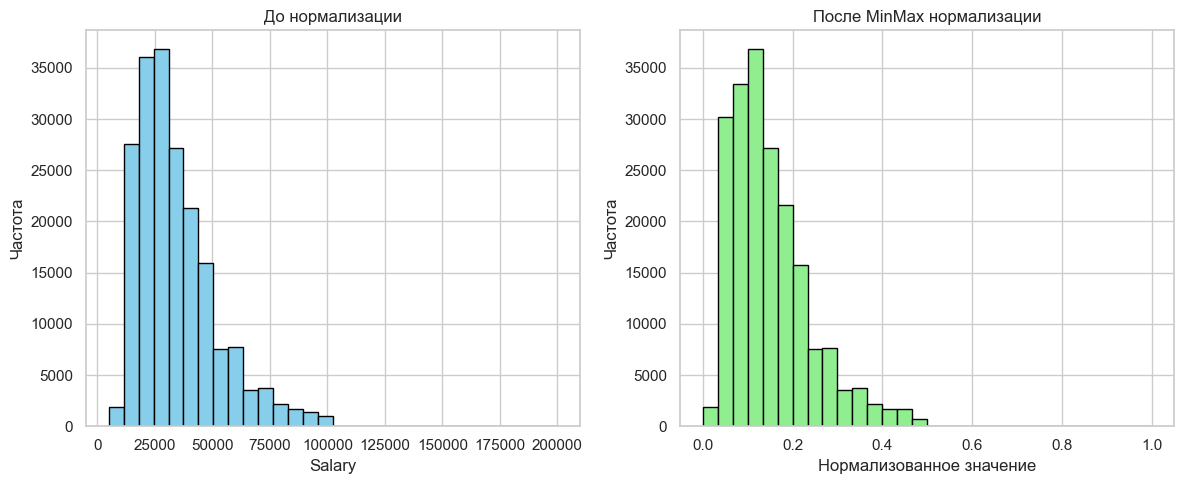

In [125]:
print("До нормализации:", train["SalaryNormalized"].values[:5])
print("После нормализации:", train_targets[:5])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train["SalaryNormalized"], bins=30, color='skyblue', edgecolor='black')
plt.title("До нормализации")
plt.xlabel("Salary")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
plt.hist(train_targets, bins=30, color='lightgreen', edgecolor='black')
plt.title("После MinMax нормализации")
plt.xlabel("Нормализованное значение")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

Сформируйте даталоадеры для обучения и валидации.

In [126]:
BATCH_SIZE = 64  # размер батча

# Инициализация загрузчиков данных для тренировочного и валидационного наборов
train_loader = DataLoader(
    # Используем тренировочный датасет, реализующий интерфейс torch.utils.data.Dataset
    train_data,
    batch_size=BATCH_SIZE,
    # Перемешивание данных перед каждой эпохой
    shuffle=True,
    # Специальная функция для обработки батча, в нашем случае паддинг текстов
    collate_fn=pad_collate,
)
valid_loader = DataLoader(
    # Используем валидационный датасет, реализующий интерфейс torch.utils.data.Dataset
    valid_data,
    batch_size=BATCH_SIZE,
    # Отключаем перемешивание для стабильной оценки
    shuffle=False,
    # Специальная функция для обработки батча, в нашем случае паддинг текстов
    collate_fn=pad_collate,
)

Наконец, можем подготовить модель. Будем использовать рекуррентную архитектуру.

In [127]:
class SimpleRNNRegressor(nn.Module):
    """Модель для задачи регрессии на основе RNN."""

    def __init__(
        self,
        num_tokens: int,
        emb_size: int = 512,
        hidden_size: int = 64,
        pad_idx: int = 0
    ):
        super(SimpleRNNRegressor, self).__init__()
        self.emb = nn.Embedding(num_tokens, emb_size, padding_idx=pad_idx)
        self.rnn = nn.RNN(input_size=emb_size, hidden_size=hidden_size, batch_first=True)
        self.regressor = nn.Linear(hidden_size, 1)
        self.pad_idx = pad_idx

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch_size, seq_len) — батч с токенами

        returns:
            (batch_size,) — предсказанные нормализованные значения
        """
        x_emb = self.emb(x)
        out, _ = self.rnn(x_emb)

        mask = (x != self.pad_idx)
        lengths = mask.sum(dim=1)

        batch_size = x.size(0)
        last_hidden = out[torch.arange(batch_size), lengths - 1]

        predictions = self.regressor(last_hidden).squeeze(1)
        return predictions


In [ ]:
def mse(preds: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(preds, y, reduction="mean")

Напишите функцию для цикла обучения и все необходимые вспомогательные функции для обучения, валидации и визуализации результатов.

In [183]:
def train(
    model: nn.Module,
    iterator: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    loss_history: List[float],
    device: torch.device = "cpu"
) -> Tuple[float, float]:
    """
    Обучение модели на одной эпохе в задаче регрессии.

    Возвращает:
        Среднее значение loss и MSE за эпоху
    """
    epoch_loss = 0.0
    epoch_mse = 0.0
    model.train()
    #i = 0
    for batch in iterator:
        #print(i)
        #i += 1
        optimizer.zero_grad()

        texts, labels = batch
        texts, labels = texts.to(device), labels.to(device)

        predictions = model(texts).squeeze() 

        loss = criterion(predictions, labels.float())
        mse = ((predictions - labels) ** 2).mean()

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_mse += mse.item()
        loss_history.append(loss.item())

    avg_loss = epoch_loss / len(iterator)
    avg_mse = epoch_mse / len(iterator)

    return avg_loss, avg_mse

def evaluate(
    model: nn.Module,
    iterator: DataLoader,
    criterion: nn.Module,
    loss_history: Optional[List[float]] = None,
    device: torch.device = "cpu"
) -> Tuple[float, float]:
    """
    Оценка модели на валидационном/тестовом наборе данных.

    Возвращает:
        Средние значения loss и MSE
    """
    epoch_loss = 0.0
    epoch_mse = 0.0
    model.eval()

    with torch.no_grad():
        for batch in iterator:
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device)

            predictions = model(texts)

            loss = criterion(predictions, labels.float())
            mse = ((predictions - labels) ** 2).mean()

            epoch_loss += loss.item()
            epoch_mse += mse.item()
            if loss_history is not None:
                loss_history.append(loss.item())

    avg_loss = epoch_loss / len(iterator)
    avg_mse = epoch_mse / len(iterator)

    return avg_loss, avg_mse

def epoch_time(start_time: float, end_time: float) -> Tuple[int, int]:
    """
    Функция для подсчёта времени работы одной эпохи.

    Параметры:
        start_time: Время начала в секундах
        end_time: Время окончания в секундах

    Возвращает:
        Минуты и секунды
    """

    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

Напишите функцию для цикла обучения и все необходимые вспомогательные функции для обучения, валидации и визуализации результатов. 

In [130]:
def training_loop(
    model_instance: nn.Module,
    criterion,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    n_epochs: int = 10,
):
    """
    Функция для обучения нейронной сети.

    Параметры.
    1) model_instance — обучаемая модель,
    2) Лосс для обучения модели
    3) Оптимизатор для обучения
    4) n_epochs — количество эпох.
    """
    best_valid_loss = float("inf")
    loss_history = []
    val_loss_history = []
    mse_history = []
    val_mse_history = []

    for epoch in range(n_epochs):
        start_time = time.time()

        # Обучим одну эпоху на обучающем датасете
        train_loss, train_mse = train(model_instance, train_loader, optimizer, criterion, loss_history)
        mse_history.append(train_mse)

        valid_loss, valid_mse = evaluate(model_instance, valid_loader, criterion, val_loss_history)
        val_mse_history.append(valid_mse)

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        clear_output(True)
        plt.figure(figsize=(18, 6))

        # Train Loss
        plt.subplot(1, 3, 1)
        plt.plot(loss_history)
        plt.title("Train Loss")
        plt.xlabel("Номер батча")

        # Valid Loss
        plt.subplot(1, 3, 2)
        plt.plot(val_loss_history, color="tab:orange")
        plt.title("Valid Loss")
        plt.xlabel("Номер батча")

        # MSE по эпохам
        plt.subplot(1, 3, 3)
        plt.plot(mse_history, label="Train MSE")
        plt.plot(val_mse_history, label="Valid MSE")
        plt.legend()
        plt.title("MSE")
        plt.xlabel("Номер эпохи")

        plt.show()

        # Сохраняем лучшую модель
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model_instance.state_dict(), "model_checkpoint.pt")

        print(f"Номер эпохи: {epoch+1:02} | Время обучения эпохи: {epoch_mins}m {epoch_secs}s")

In [131]:
num_tokens = len(vocab)
emb_size = 512
hidden_size = 64
pad_idx = vocab["<pad>"]

In [132]:
# У нас задача регрессии, будем использовать MSELoss
criterion = nn.MSELoss()

# Задайте параметры сети
model = SimpleRNNRegressor(num_tokens=num_tokens, emb_size=emb_size, hidden_size=hidden_size, pad_idx=pad_idx).to(device)
# Используем оптимизатор Adam, о нем вы сможете узнать на курсах DS-потока!
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Посмотрите на получившуюся модель
model

SimpleRNNRegressor(
  (emb): Embedding(25002, 512, padding_idx=25001)
  (rnn): RNN(512, 64, batch_first=True)
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)

**3.** Обучите несколько моделей с различными гиперпараметрами (например, шаг обучения, размер словаря, архитектура) и сравните их качество на тестовой выборке.

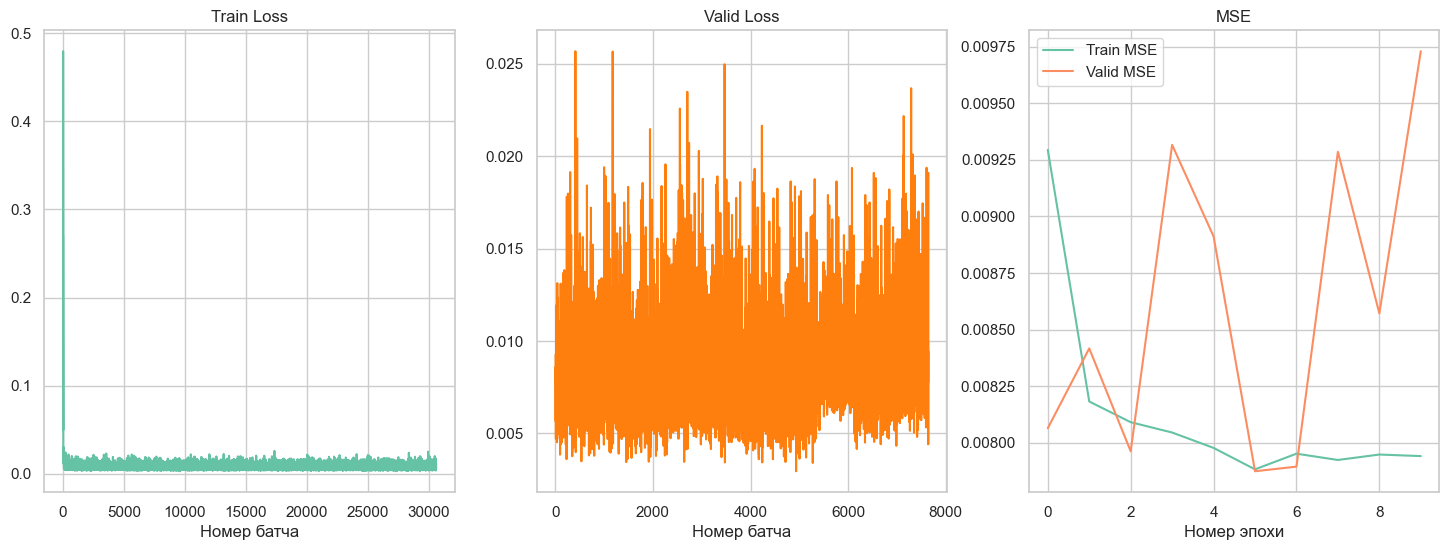

Номер эпохи: 10 | Время обучения эпохи: 46m 8s


In [ ]:
model_1 = SimpleRNNRegressor(num_tokens=num_tokens, emb_size=emb_size, hidden_size=hidden_size, pad_idx=pad_idx).to(device)
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.005)
training_loop(
    model_1,
    criterion,
    train_loader,
    valid_loader,
    optimizer
)

In [ ]:
MAX_VOCAB_SIZE = 10000
ordered_dict = OrderedDict(counter.most_common(MAX_VOCAB_SIZE))

vocab_2 = Vocabulary(ordered_dict)

vocab_2, UNK_IDX_EN, PAD_IDX_EN = add_special_tokens(vocab_2)

In [ ]:
train, val = train_test_split(dataset, test_size=0.2, random_state=42)

train_texts = [vocab_2.tokens_to_indices(simple_tokenize(text)) for text in train["FullDescription"]]
val_texts = [vocab_2.tokens_to_indices(simple_tokenize(text)) for text in val["FullDescription"]]

scaler = MinMaxScaler()
train_targets = scaler.fit_transform(train[["SalaryNormalized"]].values).flatten()
val_targets = scaler.transform(val[["SalaryNormalized"]].values).flatten()

train_data = SalaryPredictionDataset(train_texts, train_targets)
valid_data = SalaryPredictionDataset(val_texts, val_targets)

(195814, 48954)

In [173]:
BATCH_SIZE = 64  # размер батча

# Инициализация загрузчиков данных для тренировочного и валидационного наборов
train_loader = DataLoader(
    # Используем тренировочный датасет, реализующий интерфейс torch.utils.data.Dataset
    train_data,
    batch_size=BATCH_SIZE,
    # Перемешивание данных перед каждой эпохой
    shuffle=True,
    # Специальная функция для обработки батча, в нашем случае паддинг текстов
    collate_fn=pad_collate,
)
valid_loader = DataLoader(
    # Используем валидационный датасет, реализующий интерфейс torch.utils.data.Dataset
    valid_data,
    batch_size=BATCH_SIZE,
    # Отключаем перемешивание для стабильной оценки
    shuffle=False,
    # Специальная функция для обработки батча, в нашем случае паддинг текстов
    collate_fn=pad_collate,
)

In [176]:
num_tokens = len(vocab_2)
emb_size = 512
hidden_size = 64
pad_idx = vocab_2["<pad>"]

In [177]:
# словарь в два раза меньше и маленький шаг
model_2 = SimpleRNNRegressor(num_tokens=num_tokens, emb_size=emb_size, hidden_size=hidden_size, pad_idx=pad_idx).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.0001)

model_2

SimpleRNNRegressor(
  (emb): Embedding(10002, 512, padding_idx=10001)
  (rnn): RNN(512, 64, batch_first=True)
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)

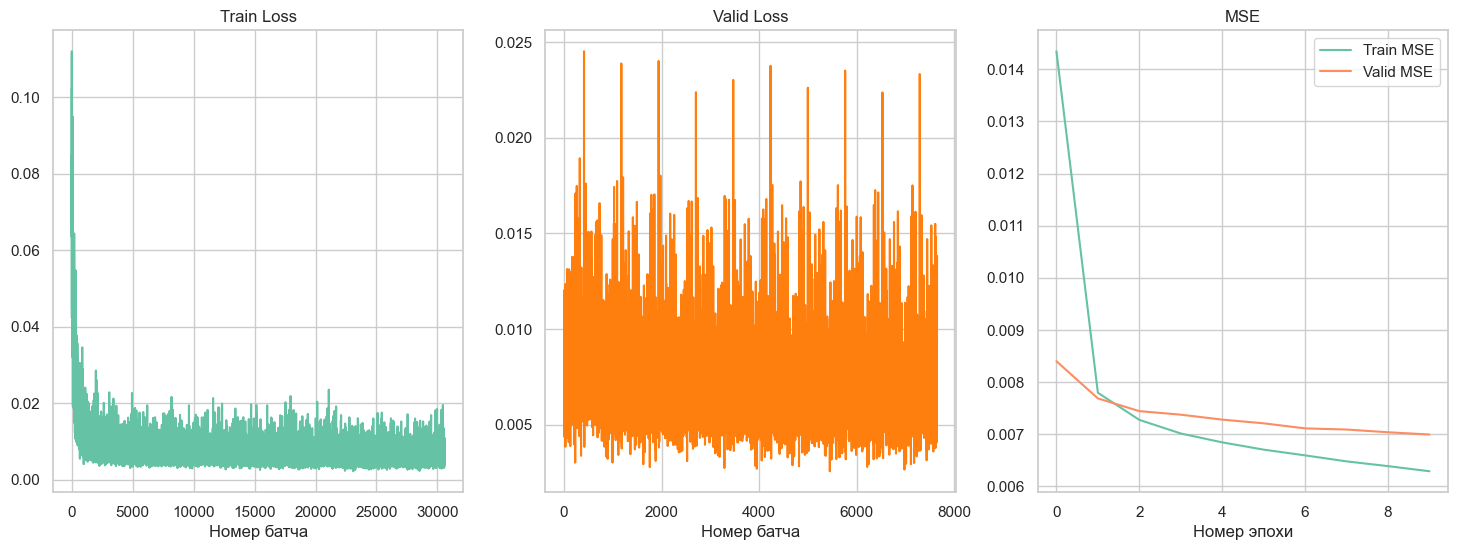

Номер эпохи: 10 | Время обучения эпохи: 37m 25s


In [184]:
training_loop(
    model_2,
    criterion,
    train_loader,
    valid_loader,
    optimizer
)

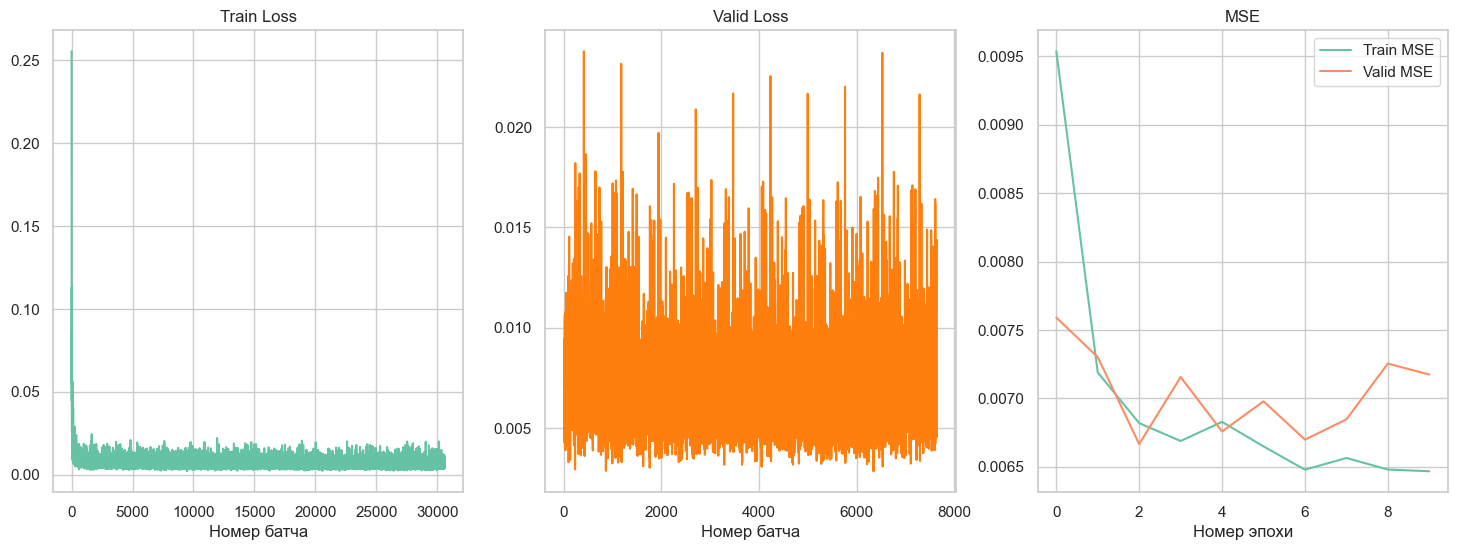

Номер эпохи: 10 | Время обучения эпохи: 31m 10s


In [189]:
# маленький размер скрытого слоя, маленький словарь
model_3 = SimpleRNNRegressor(num_tokens=num_tokens, emb_size=emb_size, hidden_size=32, pad_idx=pad_idx).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)
training_loop(
    model_3,
    criterion,
    train_loader,
    valid_loader,
    optimizer,
)

In [ ]:
losses = []
models = [model_1, model_2, model_3]

for model in models:
    loss = evaluate(model, valid_loader, criterion)
    losses.append(loss)

In [192]:
losses

[(0.012095647555428976, 0.012095647555428976),
 (0.006995184855913025, 0.006995184855913025),
 (0.007174227469801611, 0.007174227469801611)]

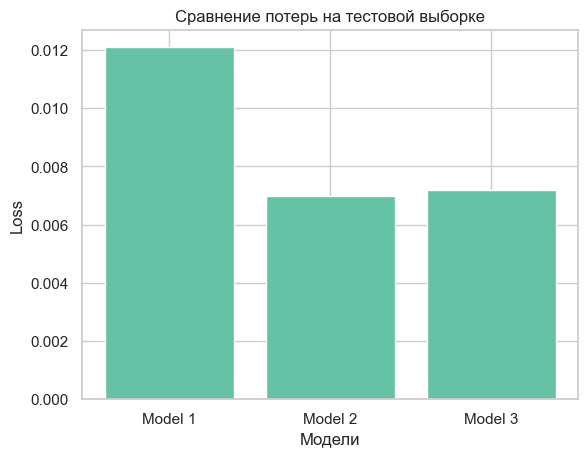

In [193]:
losses = [loss[0] for loss in losses] 

plt.bar(range(1, 4), losses, tick_label=["Model 1", "Model 2", "Model 3"])
plt.xlabel("Модели")
plt.ylabel("Loss")
plt.title("Сравнение потерь на тестовой выборке")
plt.show()

Выведите несколько примеров работы на валидационной выборке: **текст вакансии, предсказание вашей модели и истинное значение зарплаты.**

In [ ]:
def get_first_batch_predictions(models, valid_loader, device):
    """
    Получает предсказания для первого батча на каждой из моделей.

    Аргументы:
    - models: список из 3 моделей
    - valid_loader: DataLoader для валидационной выборки
    - device: torch.device (cuda или cpu)

    Возвращает:
    - labels: истинные значения
    - preds_by_model: список из 3 списков предсказаний
    """

    batch = next(iter(valid_loader))
    texts, labels = batch
    texts, labels = texts.to(device), labels.to(device)

    preds_by_model = []

    with torch.no_grad():
        for model in models:
            model.eval()
            preds = model(texts)
            preds_by_model.append(preds.cpu().numpy().flatten())
    return labels.cpu().numpy().flatten(), preds_by_model


In [ ]:
def create_predictions_dataframe(val, models, valid_loader, device):
    """
    Создаёт DataFrame с предсказаниями для первого батча.

    Аргументы:
    - models: список из 3 моделей
    - valid_loader: DataLoader для валидационной выборки

    Возвращает:
    - DataFrame с результатами
    """
    real_labels, predictions = get_first_batch_predictions(models, valid_loader, device)
    for i in range(3):
        predictions_2d = predictions[i].reshape(-1, 1)
        predictions[i] = scaler.inverse_transform(predictions_2d)
        predictions[i] = predictions[i].flatten().tolist()
    d_2 = real_labels.reshape(-1, 1)
    real_labels = scaler.inverse_transform(d_2)
    real_labels = real_labels.flatten().tolist()
    texts = val["FullDescription"][:64]

    df = pd.DataFrame({
        'Text': texts,
        'Real': real_labels,
        'Model_1_Pred': predictions[0],
        'Model_2_Pred': predictions[1],
        'Model_3_Pred': predictions[2]
    })
    return df

df_predictions = create_predictions_dataframe(val, models, valid_loader, device)

df_predictions.head()


,Text,Real,Model_1_Pred,Model_2_Pred,Model_3_Pred
30390,Business Account Manager Plumbing Heating Pro...,23500.000000,29374.601562,31957.783203,35893.339844
108709,Job Title; Staff Nurse RGN/RMN – NightsLocatio...,23040.000000,63859.980469,31249.599609,24685.076172
13924,This dynamic international development charity...,34850.000000,29374.601562,46710.886719,35461.656250
154606,Large regional law firm require a residential ...,22500.000000,63859.980469,38072.582031,34072.558594
172891,This individual will work closely with the bus...,55000.003906,29374.601562,31956.853516,35893.347656


Все модели учились просто долго на мой взгляд (примерно по 5-7 часов), поэтому мне не удалось рассмотреть много ввариантов. Первая модель сильно переобучалась (потери на валидации сильно скачут), вторая училась довольно неплохо (потери убывают нормально), третья сначала училась неплохо, потом начала переобучаться. И получилось, что потери в первой модели самые высокие, во второй и третьей ниже. Лучше всех, на мой взгляд, работает вторая модель.